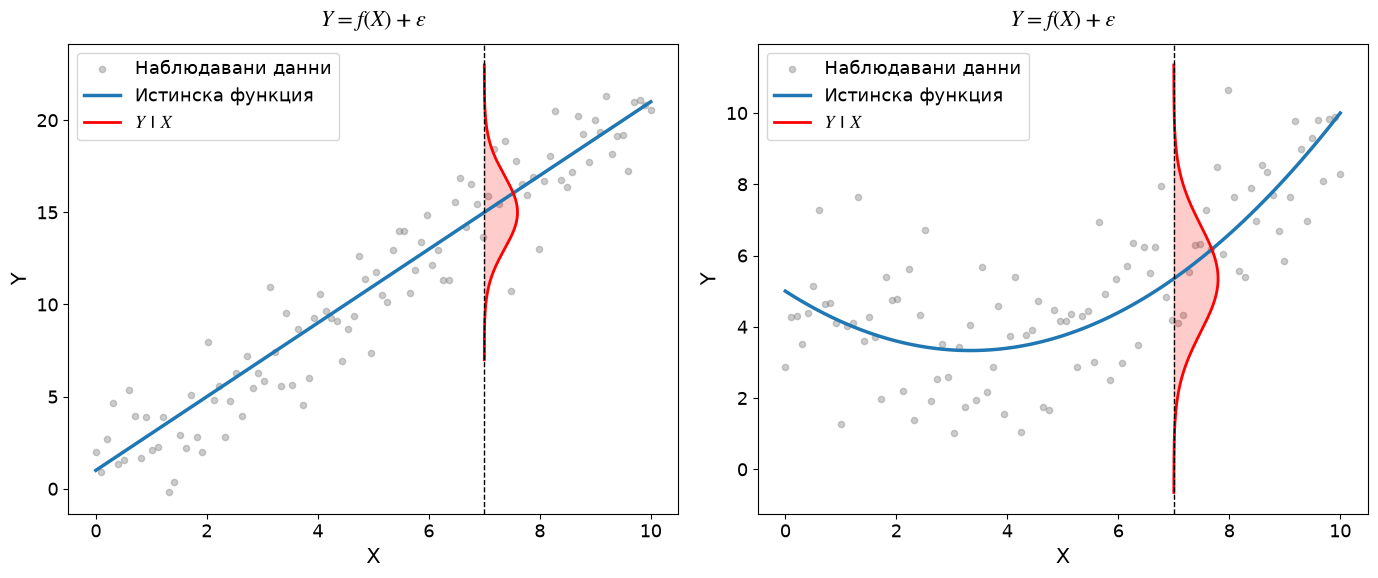

In [11]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(42)

# Настройка на шрифтовете
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'mathtext.fontset': 'stix'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

func_color = '#1f77b4'

# ----- Лява графика: Линейна функция -----
ax = axes[0]
X = np.linspace(0, 10, 100)
true_slope, true_intercept = 2.0, 1.0
y_line = true_intercept + true_slope * X
noise_std = 2.0
y_obs = y_line + np.random.normal(0, noise_std, size=X.shape)

ax.scatter(X, y_obs, alpha=0.4, color='gray', s=20, label='Наблюдавани данни')
ax.plot(X, y_line, color=func_color, linewidth=2.5, label='Истинска функция')

# Червена крива за нормалното разпределение с етикет Y|X в удебелен шрифт
x0 = 7
y0 = true_intercept + true_slope * x0
y_range = np.linspace(y0 - 4*noise_std, y0 + 4*noise_std, 200)
pdf = norm.pdf(y_range, loc=y0, scale=noise_std)
pdf_scaled = pdf * 3.0

ax.plot(x0 + pdf_scaled, y_range, color='red', linewidth=2, label=r'$Y \ | \ X$')
ax.axvline(x0, color='black', linestyle='--', linewidth=1)
ax.fill_betweenx(y_range, x0, x0 + pdf_scaled, color='red', alpha=0.2)

ax.set_title(r'$Y = f(X) + \epsilon$', pad=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

# ----- Дясна графика: Полиномиална функция -----
ax = axes[1]
true_a, true_b, true_c = 0.15, -1.0, 5.0
y_curve = true_a * X**2 + true_b * X + true_c
noise_std2 = 1.5
y_obs2 = y_curve + np.random.normal(0, noise_std2, size=X.shape)

ax.scatter(X, y_obs2, alpha=0.4, color='gray', s=20, label='Наблюдавани данни')
ax.plot(X, y_curve, color=func_color, linewidth=2.5, label='Истинска функция')

x1 = 7
y1 = true_a * x1**2 + true_b * x1 + true_c
y_range2 = np.linspace(y1 - 4*noise_std2, y1 + 4*noise_std2, 200)
pdf2 = norm.pdf(y_range2, loc=y1, scale=noise_std2)
pdf2_scaled = pdf2 * 3.0

ax.plot(x1 + pdf2_scaled, y_range2, color='red', linewidth=2, label=r'$Y \ | \ X$')
ax.axvline(x1, color='black', linestyle='--', linewidth=1)
ax.fill_betweenx(y_range2, x1, x1 + pdf2_scaled, color='red', alpha=0.2)

ax.set_title(r'$Y = f(X) + \epsilon$', pad=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

plt.tight_layout()
plt.show()